In [91]:
import pandas as pd
import os
from pathlib import Path
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
import warnings
import pickle
warnings.filterwarnings("ignore")

In [92]:
MS_natalidad = {
    "ARICA Y PARINACOTA": 1.6,
    "TARAPACA": 2.7,
    "ANTOFAGASTA": 4.0,
    "ATACAMA": 1.8,
    "COQUIMBO": 4.3,
    "VALPARAISO": 9.7,
    "METROPOLITANA": 39.6,
    "O'HIGGINS": 5.2,
    "MAULE": 6.2,
    "NUBLE": 2.7,
    "BIOBIO": 8.5,
    "ARAUCANIA": 5.5,
    "LOS RIOS": 2.1,
    "LOS LAGOS": 4.7,
    "AISEN": 0.6,
    "MAGALLANES Y ANTARTICA": 0.8
}


macrozonas = {
    "Macrozona Norte": ["ARICA Y PARINACOTA", "TARAPACA", "ANTOFAGASTA", "ATACAMA"],
    "Macrozona Centro": ["COQUIMBO", "VALPARAISO"],
    "Macrozona METROPOLITANA": ["METROPOLITANA"],
    "Macrozona Centro Sur": ["O'HIGGINS", "MAULE", "NUBLE", "BIOBIO"],
    "Macrozona Sur": ["ARAUCANIA", "LOS RIOS", "LOS LAGOS"],
    "Macrozona Austral": ["AISEN", "MAGALLANES Y ANTARTICA"]
}

# Calcular el promedio para cada macrozona
promedios_macrozonas = {
    macrozona: sum(MS_natalidad[region] for region in regiones) / len(regiones)
    for macrozona, regiones in macrozonas.items()
}

# region_a_macrozona2 = {    
#     "ARICA Y PARINACOTA": "Norte",
#     "TARAPACA": "Norte",
#     "ANTOFAGASTA": "Norte",
#     "ATACAMA": "Norte",  
#     "COQUIMBO": "Centro",  
#     "VALPARAISO": "Centro",
#     "METROPOLITANA": "Centro",
#     "O'HIGGINS": "Centro",
#     "MAULE": "Centro",  
#     "NUBLE": "Centro",
#     "BIOBIO": "Centro",
#     "ARAUCANIA": "Sur", 
#     "LOS RIOS": "Sur",
#     "LOS LAGOS": "Sur",
#     "AISEN": "Sur",
#     "MAGALLANES Y ANTARTICA": "Sur"
#     } 

# # Calcular el promedio para cada macrozona
# promedios_macrozonas2 = {
#     macrozona: sum(MS_natalidad[region] for region in regiones) / len(regiones)
#     for macrozona, regiones in region_a_macrozona2.items()
# }

In [93]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'
df_all = pd.read_csv(path_data/"data.csv")
regiones = df_all.Macrozona.unique()

In [ ]:
df_nove = (df_all
           .copy()
           .drop(columns=['Unnamed: 0'])
           .query('2021<year | year<=2020')
           .assign(FECHA_NAC = pd.to_datetime(df_all['FECHA_NAC'], errors='coerce'),
                   nac_nov=lambda x: np.where((x.FECHA_NAC.dt.year == 2019) & (x.FECHA_NAC.dt.month == 11), 1, 0),
                   year_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), 2019, x.year),
                   epiweek_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), x.epiweek + 52, x.epiweek)
           )
)

hospitalizations_total = (df_nove
                          .copy()
                          .query('elegibilidad!=year_ext')
                          .groupby(['year_ext', 'epiweek_ext', 'region'])
                          .size().reset_index(name='hospitalizations')
                          .pivot(index=['year_ext', 'epiweek_ext'], columns='region', values='hospitalizations').fillna(0)
                          .reset_index()
                          .copy()
)

hospitalizations_nov = (df_nove
                        .copy()
                        .query('elegibilidad!=year_ext')
                        .query('nac_nov == 1')
                        .groupby(['year_ext', 'epiweek_ext', 'region'])
                        .size()
                        .reset_index(name='hospitalizations')
                        .pivot(index=['year_ext', 'epiweek_ext'], columns='region', values='hospitalizations').fillna(0)
                        .reindex(columns=regiones, fill_value=0)  
                        .reset_index()
)

max_cumsum_by_region_noviembre = {}

for i in regiones:   
    
    
    hospitalizations_reg = hospitalizations_total[['year_ext', 'epiweek_ext', i]].copy().rename(columns = {i:'regional_hospitalizations'})
    
    hospitalizations_nov_reg = hospitalizations_nov[['year_ext', 'epiweek_ext',i]].copy().rename(columns = {i:'nov_hospitalizations'})
    
    hospitalizations = pd.merge(hospitalizations_reg, hospitalizations_nov_reg, on=['year_ext', 'epiweek_ext'], how='left')

    hospitalizations['nov_hospitalizations'] = hospitalizations['nov_hospitalizations'].fillna(0)

    hospitalizations['percentage_nov'] = (hospitalizations['nov_hospitalizations'] / hospitalizations['regional_hospitalizations']) * 100

    # hospitalizations = hospitalizations.assign(
    #     year_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), 2019, x.year),
    #     epiweek_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), x.epiweek + 52, x.epiweek)
    #     ).copy()
    
    
    hospitalizations_2019 = hospitalizations[hospitalizations['year_ext'] == 2019]

    hospitalizations_2024 = hospitalizations[hospitalizations['year_ext'] == 2024]

    epiweeks_2024 = hospitalizations_2024['epiweek_ext'].unique() 
    
    hospitalizations_2019_train = hospitalizations_2019[hospitalizations_2019['epiweek_ext'].isin(epiweeks_2024)]  
    hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek_ext'].isin(hospitalizations_2019_train['epiweek_ext'])]

    X_train = hospitalizations_2019_train['regional_hospitalizations'].values.reshape(-1, 1)
    y_train = hospitalizations_2024_train['regional_hospitalizations'].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    
    
    weeks_2024 = hospitalizations.query('(year_ext==2019 & epiweek_ext>=45)')['epiweek_ext'].unique() 

    # Usar las hospitalizaciones de 2022 desplazadas como entrada para predecir todo 2024
    X_full = hospitalizations.query('(year_ext==2019 & epiweek_ext>=45)')['regional_hospitalizations'].values.reshape(-1, 1)

    # Predecir usando el modelo ya entrenado
    predicted_2024_full = model.predict(X_full)
    
    predictions_df = pd.DataFrame({
        'epiweek_ext': weeks_2024,
        'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
    })

    hospitalizations_merged = hospitalizations.query('(year_ext==2019 & epiweek_ext>=45)').merge(predictions_df, on='epiweek_ext', how='left')


    hospitalizations_merged['predicted_nov_2024'] = (hospitalizations_merged['percentage_nov'] / 100) * hospitalizations_merged['predicted_2024']

    hospitalizations_merged = hospitalizations_merged[['year_ext', 'epiweek_ext', 'regional_hospitalizations', 'predicted_2024', 'percentage_nov', 'predicted_nov_2024']]

    max_cumsum_by_region_noviembre[i] = hospitalizations_merged['predicted_nov_2024'].cumsum().max()
    


plt.figure(figsize=(12, 6))

# Graficar las regiones en el eje x y sus valores máximos de cumsum en el eje y
plt.bar(max_cumsum_by_region_noviembre.keys(), max_cumsum_by_region_noviembre.values(), color='green', edgecolor='black')

# Añadir etiquetas y título
plt.xlabel('Región')
plt.ylabel('Máximo acumulado de hospitalizaciones')
plt.title('Máximo acumulado de hospitalizaciones de nacidos en noviembre 2024 por región')

# Rotar las etiquetas del eje X para evitar solapamientos
plt.xticks(rotation=45, ha='right')  # Rotación de 90 grados y alineación a la derecha

# Mostrar el gráfico
plt.tight_layout()  # Ajustar el layout para que no se corten las etiquetas
plt.show()

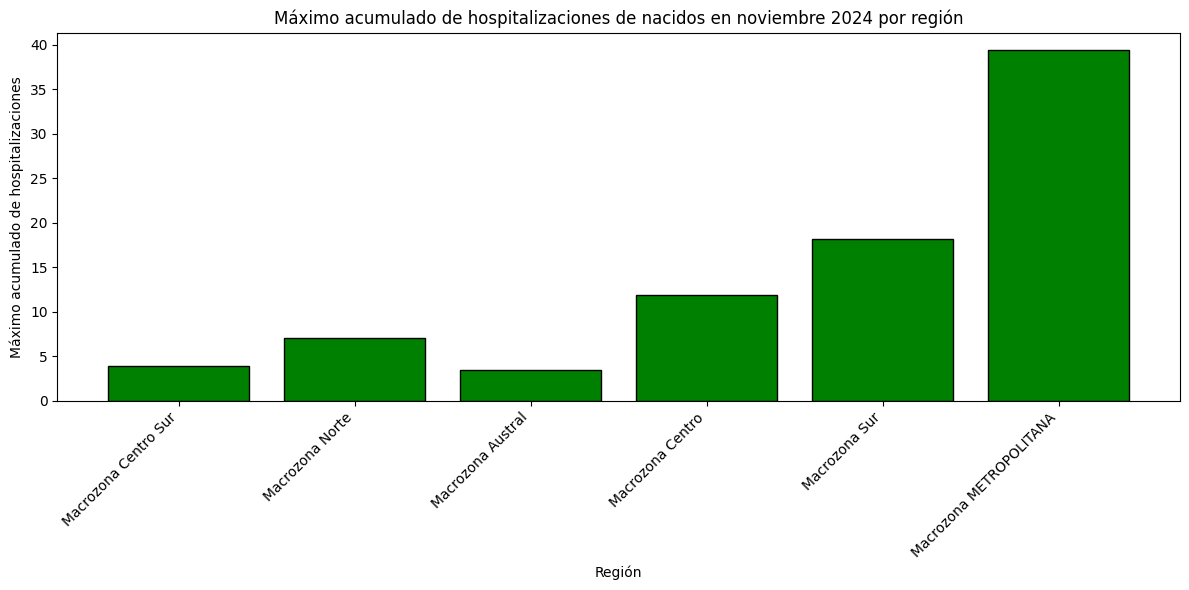

In [94]:
max_cumsum_by_region_noviembre = {}

for i in regiones:
    
    df = df_all.copy()
    
    df = (df.query(f'Macrozona=="{i}"') #region
        .drop(columns=['Unnamed: 0'])
        .query('2021<year | year<=2020')
        .assign(FECHA_NAC = pd.to_datetime(df['FECHA_NAC'], errors='coerce'),
                nac_nov=lambda x: np.where((x.FECHA_NAC.dt.year == 2019) & (x.FECHA_NAC.dt.month == 11), 1, 0),
                year_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), 2019, x.year),
                epiweek_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), x.epiweek + 52, x.epiweek)
                )
    )


    hospitalizations_by_week = df.groupby(['year_ext', 'epiweek_ext']).size().reset_index(name='hospitalizations')
    hospitalizations_by_week_elegibles = df.query('elegibilidad==year_ext').groupby(['year_ext', 'epiweek_ext']).size().reset_index(name='hospitalizations')
    hospitalizations_by_week_non_elegibles = df.query('elegibilidad!=year_ext').groupby(['year_ext', 'epiweek_ext']).size().reset_index(name='hospitalizations')

    data = hospitalizations_by_week_non_elegibles.copy()
    hospitalizations_2022 = data[data['year_ext'] == 2019]

    hospitalizations_2024 = data[data['year_ext'] == 2024]

    hospitalizations_2022['epiweek_shifted'] = hospitalizations_2022['epiweek_ext']

    epiweeks_2024 = hospitalizations_2024['epiweek_ext'].unique()  
    hospitalizations_2022_train = hospitalizations_2022[hospitalizations_2022['epiweek_shifted'].isin(epiweeks_2024)]  

    hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek_ext'].isin(hospitalizations_2022_train['epiweek_shifted'])]

    X_train = hospitalizations_2022_train['hospitalizations'].values.reshape(-1, 1)
    y_train = hospitalizations_2024_train['hospitalizations'].values

    
    model = LinearRegression()
    
    if len(X_train)==0:
        max_cumsum_by_region_noviembre[i] = 0
    else:
        model.fit(X_train, y_train)

        coeficiente = model.coef_  
        intercepto = model.intercept_  


        predicted_2024 = model.predict(X_train)

        hospitalizations_2022_full = data.query('year_ext==2019').copy()

        hospitalizations_2022_full['epiweek_shifted'] = hospitalizations_2022_full['epiweek_ext']

        X_full = hospitalizations_2022_full['hospitalizations'].values.reshape(-1, 1)

        predicted_2024_full = model.predict(X_full)

        df_note = df.query('elegibilidad!=year_ext').copy()

        hospitalizations_total = df_note.groupby(['year_ext', 'epiweek_ext']).size().reset_index(name='total_hospitalizations')

        hospitalizations_nov = df_note.query('nac_nov==1').groupby(['year_ext', 'epiweek_ext']).size().reset_index(name='nov_hospitalizations')

        hospitalizations = pd.merge(hospitalizations_total, hospitalizations_nov, on=['year_ext', 'epiweek_ext'], how='left')

        hospitalizations['nov_hospitalizations'] = hospitalizations['nov_hospitalizations'].fillna(0)

        hospitalizations['epiweek_shifted'] = hospitalizations['epiweek_ext'] 

        hospitalizations['percentage_nov'] = (hospitalizations['nov_hospitalizations'] / hospitalizations['total_hospitalizations']) * 100


        weeks_2024 = hospitalizations.query('(year_ext==2019 & epiweek_ext>=45)')['epiweek_ext'].unique() 

        X_full = hospitalizations.query('(year_ext==2019 & epiweek_ext>=45)')['nov_hospitalizations'].values.reshape(-1, 1)
        
        if len(X_full)==0:
            predicted_2024_full = np.zeros(len(weeks_2024))
        else:
            predicted_2024_full = model.predict(X_full)
        
        predictions_df = pd.DataFrame({
            'epiweek_ext': weeks_2024,
            'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
        })

        hospitalizations_merged = hospitalizations.query('((year_ext == 2020) & (epiweek_ext <= 13)) | ((year_ext==2019 & epiweek_ext>=45))').merge(predictions_df, on='epiweek_ext', how='left')


        hospitalizations_merged['predicted_nov_2024'] = (hospitalizations_merged['percentage_nov'] / 100) * hospitalizations_merged['predicted_2024']

        hospitalizations_merged = hospitalizations_merged[['year_ext', 'epiweek_ext', 'total_hospitalizations', 'predicted_2024', 'percentage_nov', 'predicted_nov_2024']]
        
        max_cumsum_by_region_noviembre[i] = hospitalizations_merged['predicted_nov_2024'].cumsum().max()
    
plt.figure(figsize=(12, 6))

# Graficar las regiones en el eje x y sus valores máximos de cumsum en el eje y
plt.bar(max_cumsum_by_region_noviembre.keys(), max_cumsum_by_region_noviembre.values(), color='green', edgecolor='black')

# Añadir etiquetas y título
plt.xlabel('Región')
plt.ylabel('Máximo acumulado de hospitalizaciones')
plt.title('Máximo acumulado de hospitalizaciones de nacidos en noviembre 2024 por región')

# Rotar las etiquetas del eje X para evitar solapamientos
plt.xticks(rotation=45, ha='right')  # Rotación de 90 grados y alineación a la derecha

# Mostrar el gráfico
plt.tight_layout()  # Ajustar el layout para que no se corten las etiquetas
plt.show()

In [99]:
promedios_macrozonas

{'Macrozona Norte': 2.5250000000000004,
 'Macrozona Centro': 7.0,
 'Macrozona METROPOLITANA': 39.6,
 'Macrozona Centro Sur': 5.65,
 'Macrozona Sur': 4.1000000000000005,
 'Macrozona Austral': 0.7}

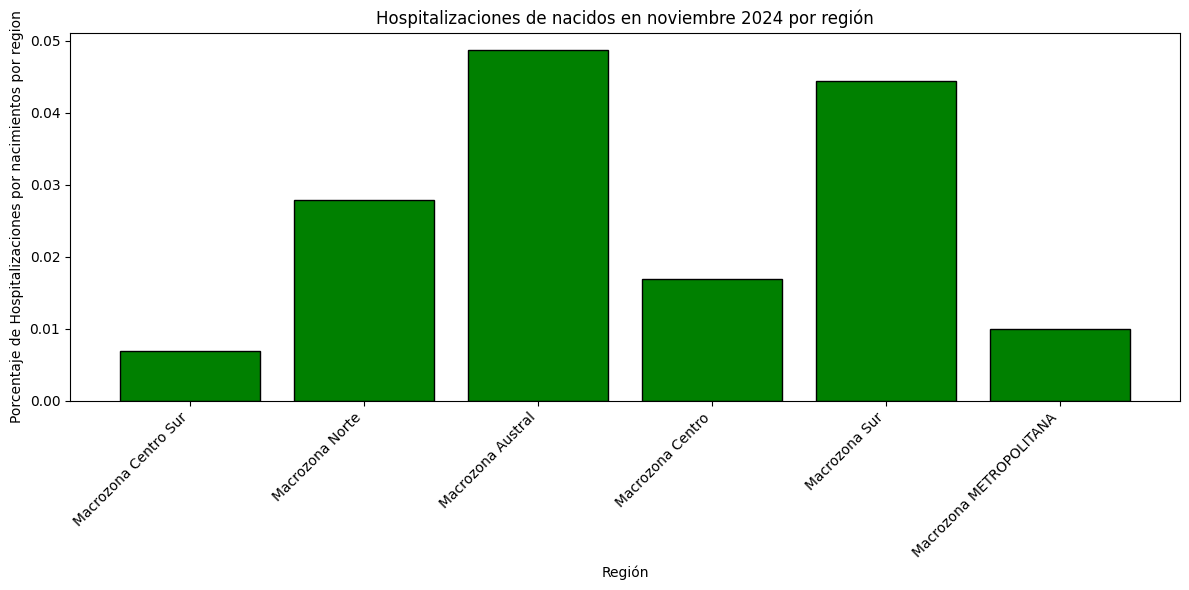

In [100]:
producto_punto_dict_nov = {key: max_cumsum_by_region_noviembre[key] / (promedios_macrozonas[key] * 100) for key in max_cumsum_by_region_noviembre}

plt.figure(figsize=(12, 6))

plt.bar(producto_punto_dict_nov.keys(), producto_punto_dict_nov.values(), color='green', edgecolor='black')

plt.xlabel('Región')
plt.ylabel('Porcentaje de Hospitalizaciones por nacimientos por region')
plt.title('Hospitalizaciones de nacidos en noviembre 2024 por región')

# Rotar las etiquetas del eje X para evitar solapamientos
plt.xticks(rotation=45, ha='right')  # Rotación de 90 grados y alineación a la derecha

# Mostrar el gráfico
plt.tight_layout()  # Ajustar el layout para que no se corten las etiquetas
plt.show()

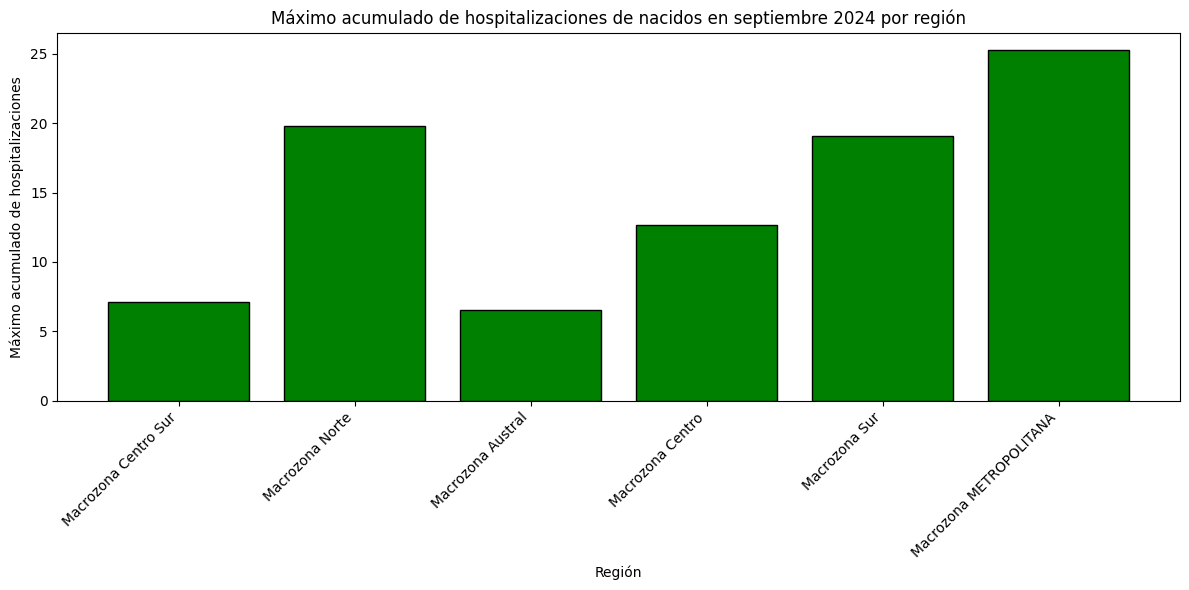

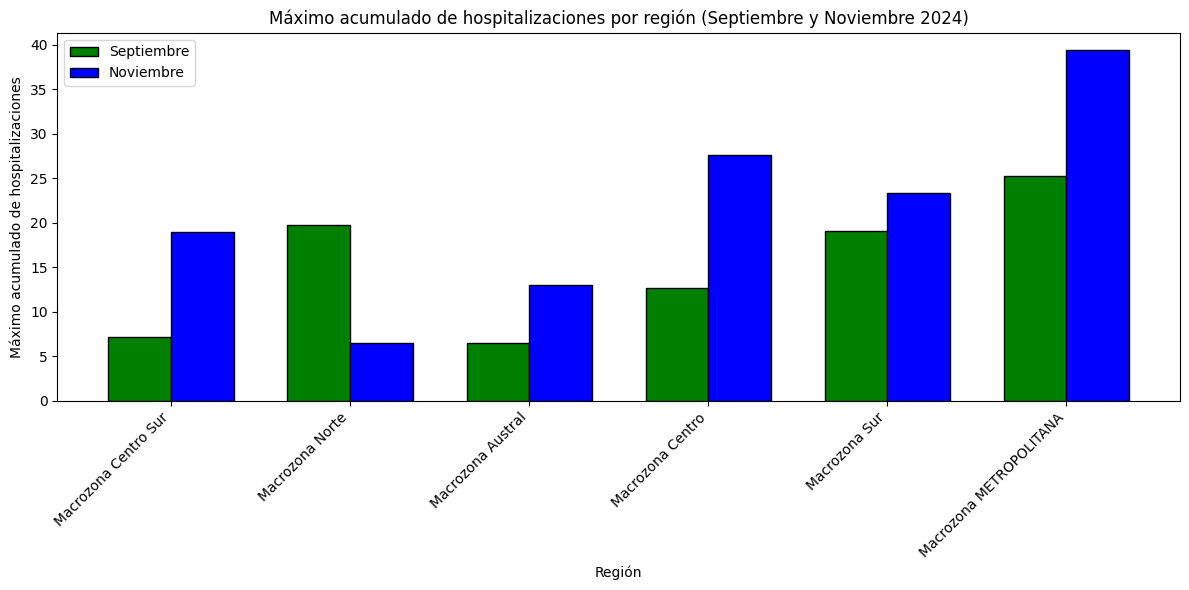

In [89]:
max_cumsum_by_region_septiembre = {}


for i in regiones:
    df = df_all.copy()
    df = (df
        .query(f'Macrozona=="{i}"')
        .drop(columns=['Unnamed: 0'])
        .query('2021<year | year<=2020')
        .assign(FECHA_NAC = pd.to_datetime(df['FECHA_NAC'], errors='coerce'),
                nac_nov=lambda x: np.where((x.FECHA_NAC.dt.year == 2019) & (x.FECHA_NAC.dt.month == 11), 1, 0),
                nac_sep=lambda x: np.where((x.FECHA_NAC.dt.year == 2018) & (x.FECHA_NAC.dt.month == 9), 1, 0))
        .copy()
    )

    hospitalizations_by_week = df.groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')
    hospitalizations_by_week_elegibles = df.query('elegibilidad==year').groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')
    hospitalizations_by_week_non_elegibles = df.query('elegibilidad!=year').groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')

    data = hospitalizations_by_week_non_elegibles.copy()

    hospitalizations_2019 = data[data['year'] == 2019]

    hospitalizations_2024 = data[data['year'] == 2024]

    hospitalizations_2019['epiweek_shifted'] = hospitalizations_2019['epiweek']

    epiweeks_2024 = hospitalizations_2024['epiweek'].unique()  
    hospitalizations_2019_train = hospitalizations_2019[hospitalizations_2019['epiweek_shifted'].isin(epiweeks_2024)]  

    hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek'].isin(hospitalizations_2019_train['epiweek_shifted'])]

    X_train = hospitalizations_2019_train['hospitalizations'].values.reshape(-1, 1)
    y_train = hospitalizations_2024_train['hospitalizations'].values

    model = LinearRegression()
    model.fit(X_train, y_train)

    coeficiente = model.coef_  
    intercepto = model.intercept_  

    predicted_2024 = model.predict(X_train)


    hospitalizations_2019_full = data.query('year==2019').copy()

    hospitalizations_2019_full['epiweek_shifted'] = hospitalizations_2019_full['epiweek']

    # Usar las hospitalizaciones de 2019 desplazadas como entrada para predecir todo 2024
    X_full = hospitalizations_2019_full['hospitalizations'].values.reshape(-1, 1)

    # Predecir usando el modelo ya entrenado
    predicted_2024_full = model.predict(X_full)

    df_note = df.query('elegibilidad!=year')

    hospitalizations_total = df_note.groupby(['year', 'epiweek']).size().reset_index(name='total_hospitalizations')

    hospitalizations_sep = df_note[df_note['nac_sep'] == 1].groupby(['year', 'epiweek']).size().reset_index(name='sep_hosptialization')

    hospitalizations = pd.merge(hospitalizations_total, hospitalizations_sep, on=['year', 'epiweek'], how='left')

    hospitalizations['sep_hosptialization'] = hospitalizations['sep_hosptialization'].fillna(0)

    hospitalizations['percentage_sep'] = (hospitalizations['sep_hosptialization'] / hospitalizations['total_hospitalizations']) * 100

    weeks_2024 = hospitalizations.query('year==2019')['epiweek'].unique() 

    X_full = hospitalizations.query('year==2019')['sep_hosptialization'].values.reshape(-1, 1)

    predicted_2024_full = model.predict(X_full)

    predictions_df = pd.DataFrame({
        'epiweek': weeks_2024,
        'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
    })

    hospitalizations_merged = hospitalizations.query('year==2019').merge(predictions_df, on='epiweek', how='left')

    hospitalizations_merged['predicted_sep_2024'] = (hospitalizations_merged['percentage_sep'] / 100) * hospitalizations_merged['predicted_2024']

    hospitalizations_merged = hospitalizations_merged[['year', 'epiweek', 'total_hospitalizations', 'predicted_2024', 'percentage_sep', 'predicted_sep_2024']]

    hospitalizations_filtered = hospitalizations_merged[(hospitalizations_merged['epiweek'] >= 14) & (hospitalizations_merged['epiweek'] <= 40)]
  
    max_cumsum_by_region_septiembre[i] = hospitalizations_filtered['predicted_sep_2024'].cumsum().max()
    
    
plt.figure(figsize=(12, 6))

plt.bar(max_cumsum_by_region_septiembre.keys(), max_cumsum_by_region_septiembre.values(), color='green', edgecolor='black')


plt.xlabel('Región')
plt.ylabel('Máximo acumulado de hospitalizaciones')
plt.title('Máximo acumulado de hospitalizaciones de nacidos en septiembre 2024 por región')


plt.xticks(rotation=45, ha='right')  


plt.tight_layout()  
plt.show()

# Unir los datos de ambos gráficos
regiones = list(max_cumsum_by_region_septiembre.keys())
septiembre_values = list(max_cumsum_by_region_septiembre.values())
noviembre_values = list(max_cumsum_by_region_noviembre.values())

# Índice para las regiones en el eje X
x = np.arange(len(regiones))

# Ancho de las barras
bar_width = 0.35

# Crear el gráfico con barras agrupadas
plt.figure(figsize=(12, 6))

# Graficar las barras para septiembre
plt.bar(x - bar_width/2, septiembre_values, bar_width, label='Septiembre', color='green', edgecolor='black')

# Graficar las barras para noviembre
plt.bar(x + bar_width/2, noviembre_values, bar_width, label='Noviembre', color='blue', edgecolor='black')

# Añadir etiquetas y título
plt.xlabel('Región')
plt.ylabel('Máximo acumulado de hospitalizaciones')
plt.title('Máximo acumulado de hospitalizaciones por región (Septiembre y Noviembre 2024)')

# Añadir las etiquetas de las regiones en el eje X
plt.xticks(x, regiones, rotation=45, ha='right')

# Añadir leyenda
plt.legend()

# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar el gráfico
plt.show()

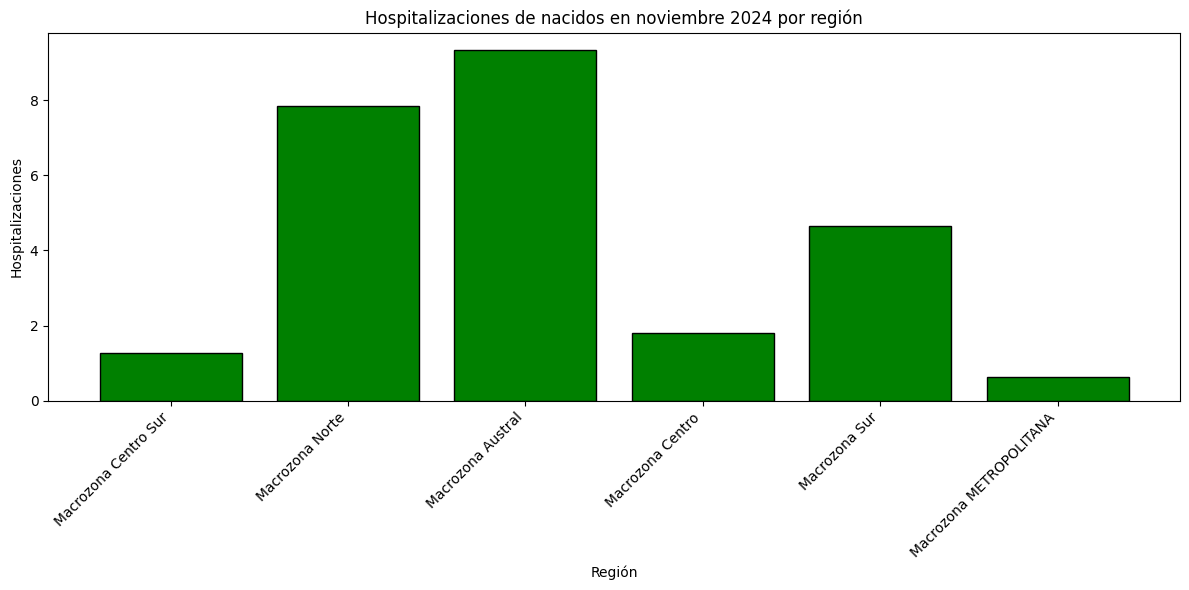

In [90]:
producto_punto_dict_sep = {key: max_cumsum_by_region_septiembre[key] / promedios_macrozonas[key] for key in max_cumsum_by_region_noviembre}

plt.figure(figsize=(12, 6))

# Graficar las regiones en el eje x y sus valores máximos de cumsum en el eje y
plt.bar(producto_punto_dict_sep.keys(), producto_punto_dict_sep.values(), color='green', edgecolor='black')

# Añadir etiquetas y título
plt.xlabel('Región')
plt.ylabel('Hospitalizaciones')
plt.title('Hospitalizaciones de nacidos en noviembre 2024 por región')

# Rotar las etiquetas del eje X para evitar solapamientos
plt.xticks(rotation=45, ha='right')  # Rotación de 90 grados y alineación a la derecha

# Mostrar el gráfico
plt.tight_layout()  # Ajustar el layout para que no se corten las etiquetas
plt.show()

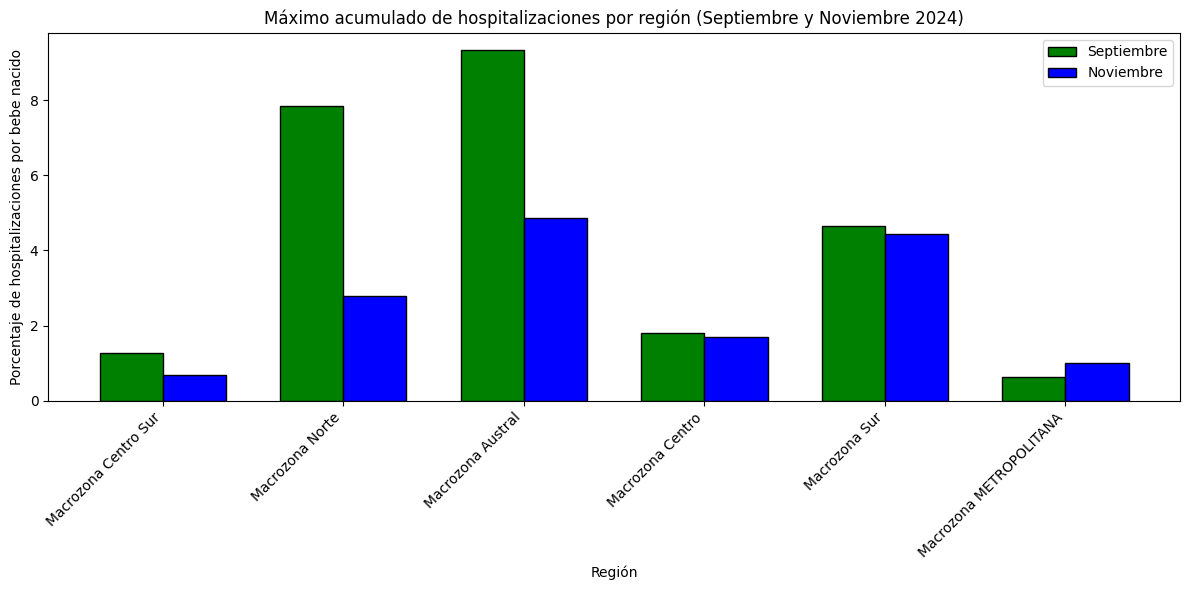

In [81]:
# Unir los datos de ambos gráficos
regiones = list(producto_punto_dict_sep.keys())
septiembre_values = list(producto_punto_dict_sep.values())
noviembre_values = list(producto_punto_dict_nov.values())

# Índice para las regiones en el eje X
x = np.arange(len(regiones))

# Ancho de las barras
bar_width = 0.35

# Crear el gráfico con barras agrupadas
plt.figure(figsize=(12, 6))

# Graficar las barras para septiembre
plt.bar(x - bar_width/2, septiembre_values, bar_width, label='Septiembre', color='green', edgecolor='black')

# Graficar las barras para noviembre
plt.bar(x + bar_width/2, noviembre_values, bar_width, label='Noviembre', color='blue', edgecolor='black')

# Añadir etiquetas y título
plt.xlabel('Región')
plt.ylabel('Porcentaje de hospitalizaciones por bebe nacido')
plt.title('Máximo acumulado de hospitalizaciones por región (Septiembre y Noviembre 2024)')

# Añadir las etiquetas de las regiones en el eje X
plt.xticks(x, regiones, rotation=45, ha='right')

# Añadir leyenda
plt.legend()

# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [43]:
total_sep = 0
total_nov = 0 
for i in regiones:
    
    if pd.isnull(max_cumsum_by_region_septiembre[i]):
        total_sep += 0
    
    else:
        total_sep += max_cumsum_by_region_septiembre[i]

    if pd.isnull(max_cumsum_by_region_noviembre[i]):
        total_nov += 0
        
    else:
        total_nov += max_cumsum_by_region_noviembre[i]
    
print(total_sep, total_nov)

130.86774413343875 103.19945017528252
